# Business Analytics Assignment
## Part 1: Customer Lifetime Value (CLV) Prediction
## Part 2: Remote Work Analysis — Clustering & At-Risk Classification

---
# PART 1 — Customer Lifetime Value (CLV) Regression

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the CLV dataset 
clv_df = pd.read_csv('../../shared/Assignment 2/subscription_clv_data.csv')
print('Shape:', clv_df.shape)
clv_df.head()

Shape: (1000, 11)


,Subscription_Length,Monthly_Spend,Total_Orders,Customer_Age,Gender,Region,Payment_Type,Referral_Source,Discount_Applied,Engagement_Score,Customer_Lifetime_Value
0,29,33.93,35,30,Female,Europe,Credit Card,Google Ads,No,80,2575.42
1,15,31.67,21,24,Male,North America,Credit Card,Friends & Family,No,90,1690.24
2,8,35.34,11,53,Male,North America,Other,Friends & Family,Yes,33,790.72
3,21,20.32,23,64,Female,Europe,PayPal,Friends & Family,Yes,31,1467.92
4,19,15.57,26,68,Male,North America,Credit Card,Google Ads,No,47,1171.04


In [9]:
clv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Subscription_Length      1000 non-null   int64  
 1   Monthly_Spend            1000 non-null   float64
 2   Total_Orders             1000 non-null   int64  
 3   Customer_Age             1000 non-null   int64  
 4   Gender                   1000 non-null   object 
 5   Region                   1000 non-null   object 
 6   Payment_Type             1000 non-null   object 
 7   Referral_Source          1000 non-null   object 
 8   Discount_Applied         1000 non-null   object 
 9   Engagement_Score         1000 non-null   int64  
 10  Customer_Lifetime_Value  1000 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 86.1+ KB


In [10]:
clv_df.describe()

,Subscription_Length,Monthly_Spend,Total_Orders,Customer_Age,Engagement_Score,Customer_Lifetime_Value
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,18.398000,31.008280,22.789000,43.721000,50.214000,1546.814260
std,10.389588,12.249255,10.678319,15.211066,29.056367,943.352904
min,1.000000,5.000000,1.000000,18.000000,1.000000,112.450000
25%,9.000000,20.255000,14.000000,31.000000,24.750000,801.270000
50%,19.000000,31.470000,23.000000,44.000000,49.500000,1320.470000
75%,28.000000,41.402500,32.000000,57.000000,77.000000,2123.717500
max,35.000000,60.000000,44.000000,69.000000,99.000000,4657.520000


## 1.1 Exploratory Data Analysis (EDA)

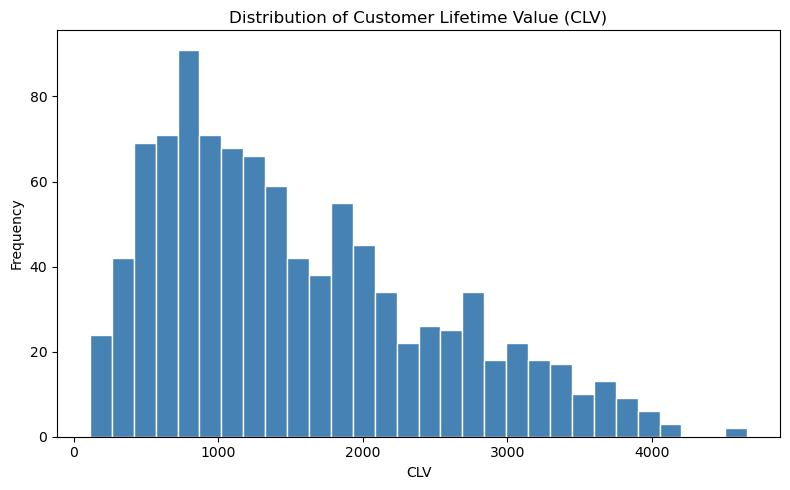

In [11]:
# Distribution of CLV
plt.figure(figsize=(8, 5))
plt.hist(clv_df['Customer_Lifetime_Value'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Customer Lifetime Value (CLV)')
plt.xlabel('CLV')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

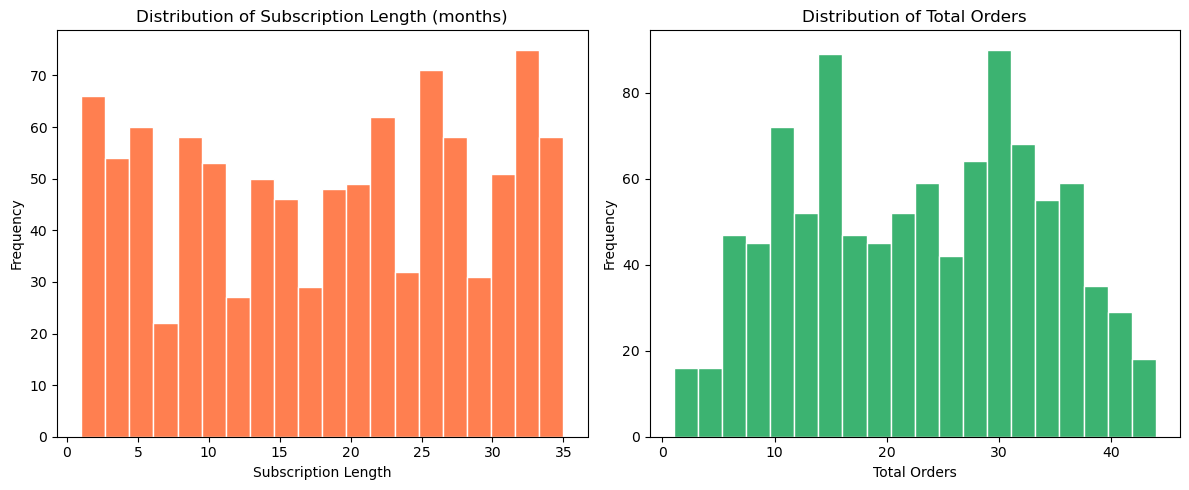

In [12]:
# Distribution of Subscription Length and Total Orders
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(clv_df['Subscription_Length'], bins=20, color='coral', edgecolor='white')
axes[0].set_title('Distribution of Subscription Length (months)')
axes[0].set_xlabel('Subscription Length')
axes[0].set_ylabel('Frequency')

axes[1].hist(clv_df['Total_Orders'], bins=20, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Distribution of Total Orders')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

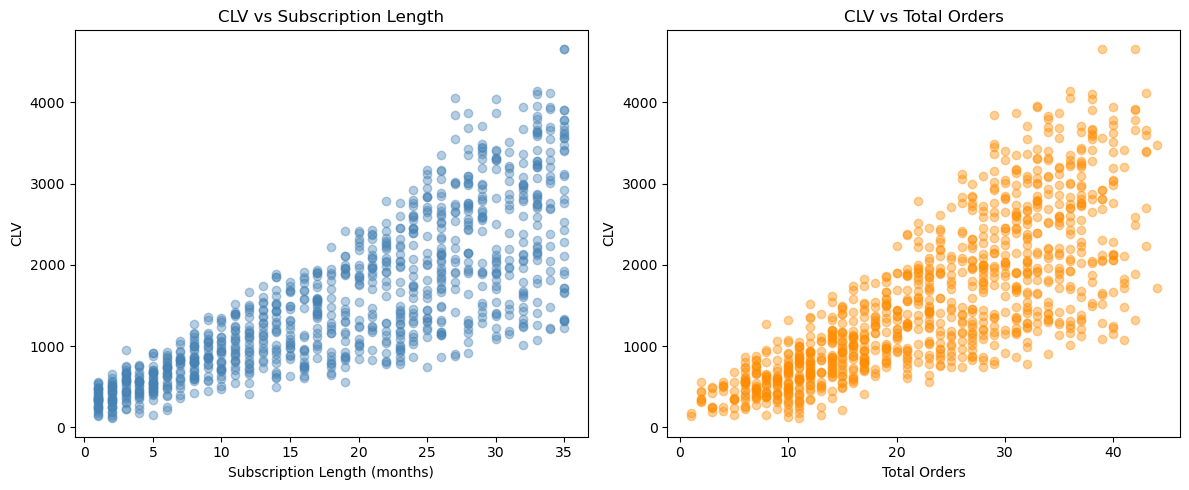

In [13]:
# Scatter plots: CLV vs Subscription Length and CLV vs Total Orders
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(clv_df['Subscription_Length'], clv_df['Customer_Lifetime_Value'],
                alpha=0.4, color='steelblue')
axes[0].set_title('CLV vs Subscription Length')
axes[0].set_xlabel('Subscription Length (months)')
axes[0].set_ylabel('CLV')

axes[1].scatter(clv_df['Total_Orders'], clv_df['Customer_Lifetime_Value'],
                alpha=0.4, color='darkorange')
axes[1].set_title('CLV vs Total Orders')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('CLV')

plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

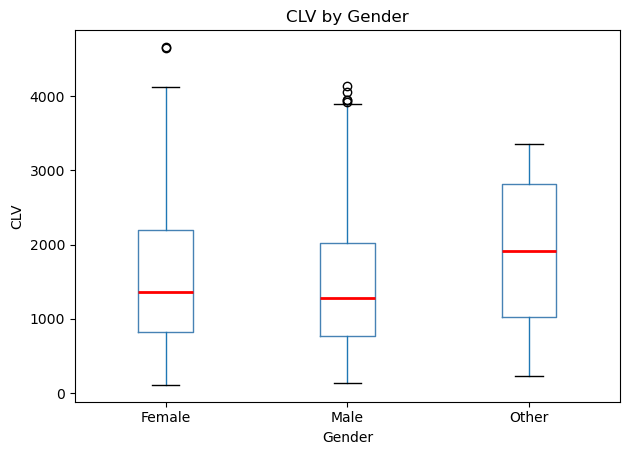

In [14]:
# Box plots: CLV by Gender
plt.figure(figsize=(7, 5))
clv_df.boxplot(column='Customer_Lifetime_Value', by='Gender', grid=False,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
plt.title('CLV by Gender')
plt.suptitle('')
plt.xlabel('Gender')
plt.ylabel('CLV')
plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

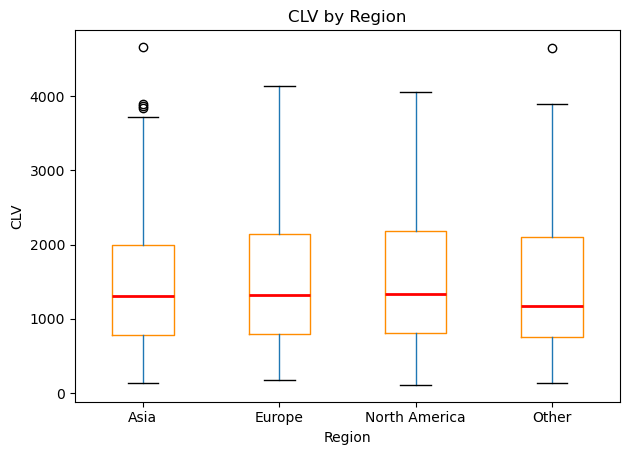

In [15]:
# Box plots: CLV by Region
plt.figure(figsize=(9, 5))
clv_df.boxplot(column='Customer_Lifetime_Value', by='Region', grid=False,
               boxprops=dict(color='darkorange'),
               medianprops=dict(color='red', linewidth=2))
plt.title('CLV by Region')
plt.suptitle('')
plt.xlabel('Region')
plt.ylabel('CLV')
plt.tight_layout()
plt.show()

    Referral_Source Discount_Applied  Customer_Lifetime_Value
0  Friends & Family               No              1668.167971
1  Friends & Family              Yes              1606.514074
2        Google Ads               No              1586.417248
3        Google Ads              Yes              1421.551810
4             Other               No              1499.986232
5             Other              Yes              1139.055000
6      Social Media               No              1570.777236
7      Social Media              Yes              1401.377614


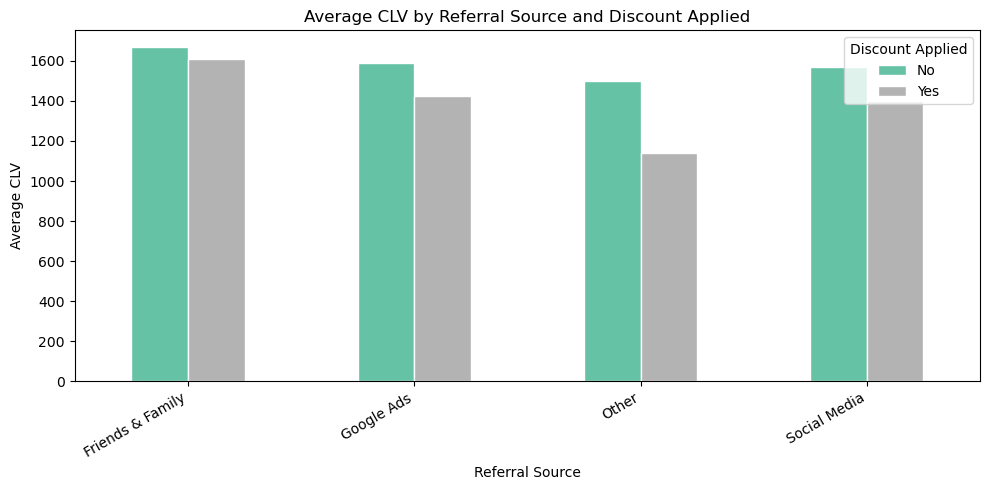

In [16]:
# Average CLV by Referral Source and Discount Applied
avg_clv = (clv_df
           .groupby(['Referral_Source', 'Discount_Applied'])['Customer_Lifetime_Value']
           .mean()
           .reset_index())
print(avg_clv)

pivot = avg_clv.pivot(index='Referral_Source', columns='Discount_Applied',
                      values='Customer_Lifetime_Value')

pivot.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Average CLV by Referral Source and Discount Applied')
plt.xlabel('Referral Source')
plt.ylabel('Average CLV')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Discount Applied')
plt.tight_layout()
plt.show()

## 1.2 Data Preparation

In [17]:
# Check for missing values
print('Missing values:')
print(clv_df.isnull().sum())

Missing values:
Subscription_Length        0
Monthly_Spend              0
Total_Orders               0
Customer_Age               0
Gender                     0
Region                     0
Payment_Type               0
Referral_Source            0
Discount_Applied           0
Engagement_Score           0
Customer_Lifetime_Value    0
dtype: int64


In [18]:
# One-hot encoding for categorical columns
categorical_cols = ['Gender', 'Region', 'Payment_Type', 'Referral_Source', 'Discount_Applied']
clv_encoded = pd.get_dummies(clv_df, columns=categorical_cols, drop_first=True)

print('Shape after encoding:', clv_encoded.shape)
print('Columns:', clv_encoded.columns.tolist())

Shape after encoding: (1000, 17)
Columns: ['Subscription_Length', 'Monthly_Spend', 'Total_Orders', 'Customer_Age', 'Engagement_Score', 'Customer_Lifetime_Value', 'Gender_Male', 'Gender_Other', 'Region_Europe', 'Region_North America', 'Region_Other', 'Payment_Type_Other', 'Payment_Type_PayPal', 'Referral_Source_Google Ads', 'Referral_Source_Other', 'Referral_Source_Social Media', 'Discount_Applied_Yes']


In [19]:
# Scale numerical features
numerical_cols = ['Customer_Age', 'Subscription_Length', 'Total_Orders',
                  'Monthly_Spend', 'Engagement_Score']

scaler = StandardScaler()
clv_encoded[numerical_cols] = scaler.fit_transform(clv_encoded[numerical_cols])

clv_encoded.head()

,Subscription_Length,Monthly_Spend,Total_Orders,Customer_Age,Engagement_Score,Customer_Lifetime_Value,Gender_Male,Gender_Other,Region_Europe,Region_North America,Region_Other,Payment_Type_Other,Payment_Type_PayPal,Referral_Source_Google Ads,Referral_Source_Other,Referral_Source_Social Media,Discount_Applied_Yes
0,1.020955,0.238642,1.144104,-0.902492,1.025624,2575.42,False,False,True,False,False,False,False,True,False,False,False
1,-0.327222,0.054048,-0.167620,-1.297139,1.369955,1690.24,True,False,False,True,False,False,False,False,False,False,False
2,-1.001310,0.353808,-1.104565,0.610322,-0.592731,790.72,True,False,False,True,False,True,False,False,False,False,True
3,0.250568,-0.873002,0.019770,1.333841,-0.661597,1467.92,False,False,True,False,False,False,True,False,False,False,True
4,0.057972,-1.260975,0.300853,1.596939,-0.110668,1171.04,True,False,False,True,False,False,False,True,False,False,False


## 1.3 Modelling — Linear Regression

In [20]:
# Define features and target
X = clv_encoded.drop(columns=['Customer_Lifetime_Value'])
y = clv_encoded['Customer_Lifetime_Value']

# Convert boolean columns to int (from one-hot encoding)
X = X.astype(float)

# Train/test split — 80/20, random_state=0
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 800
Test size: 200


In [21]:
# Fit Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Evaluate on test set
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R-squared on test set: {r2:.4f}')

R-squared on test set: 0.9095


Top influential features:
                     Feature  Coefficient
         Subscription_Length   623.710733
               Monthly_Spend   470.229691
        Region_North America   159.909138
       Referral_Source_Other  -151.288451
  Referral_Source_Google Ads  -136.078953
               Region_Europe   115.030361
Referral_Source_Social Media  -111.520711
                Total_Orders    88.911602
            Engagement_Score    86.716568
                Gender_Other    54.526996
          Payment_Type_Other    30.510922
         Payment_Type_PayPal    16.618093
        Discount_Applied_Yes   -16.582466
                Region_Other    16.538779
                Customer_Age     8.584374


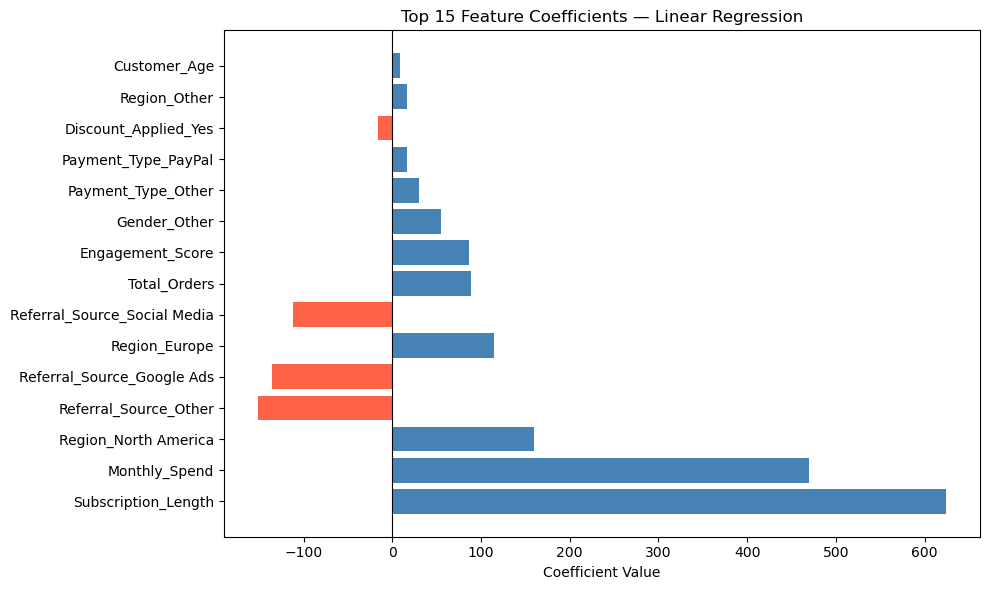

In [22]:
# Feature importance — model coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Top influential features:')
print(coef_df.head(15).to_string(index=False))

# Plot top 15 coefficients
top15 = coef_df.head(15)
colors = ['steelblue' if c > 0 else 'tomato' for c in top15['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(top15['Feature'], top15['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients — Linear Regression')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 1.4 Insights and Business Questions

In [23]:
# Q1: What insights can help increase CLV?
print("""
INSIGHT 1 — INCREASING CLV
===========================
From the model coefficients and EDA:
- Subscription Length and Monthly Spend are the strongest positive predictors of CLV.
  Retaining customers longer and upselling monthly add-ons will drive higher lifetime value.
- Engagement Score has a meaningful positive coefficient, suggesting that customers who
  actively interact with promotions and surveys tend to have higher CLV. Investing in
  personalised engagement campaigns (surveys, loyalty rewards, targeted promotions) is
  recommended.
- Total Orders also correlates positively with CLV. Encouraging repeat purchases through
  loyalty programmes or auto-renew incentives can boost this metric.
""")


INSIGHT 1 — INCREASING CLV
From the model coefficients and EDA:
- Subscription Length and Monthly Spend are the strongest positive predictors of CLV.
  Retaining customers longer and upselling monthly add-ons will drive higher lifetime value.
- Engagement Score has a meaningful positive coefficient, suggesting that customers who
  actively interact with promotions and surveys tend to have higher CLV. Investing in
  personalised engagement campaigns (surveys, loyalty rewards, targeted promotions) is
  recommended.
- Total Orders also correlates positively with CLV. Encouraging repeat purchases through
  loyalty programmes or auto-renew incentives can boost this metric.



In [24]:
# Q2: Should discounts continue?
disc_clv = clv_df.groupby('Discount_Applied')['Customer_Lifetime_Value'].agg(['mean', 'median', 'count'])
print('CLV statistics by Discount Applied:')
print(disc_clv)


CLV statistics by Discount Applied:
                         mean   median  count
Discount_Applied                             
No                1589.550057  1368.06    704
Yes               1445.172365  1143.92    296

INSIGHT 2 — DISCOUNT STRATEGY
The bar chart (section 1.1) and the table above show whether customers who used a discount
at sign-up have higher or lower average CLV compared to non-discounted customers.
- If the mean CLV for 'Yes' is lower, discounts attract price-sensitive customers with
  shorter retention, and the company should reconsider blanket discount offerings.
- If mean CLV is similar or higher, targeted discounts can be justified as an acquisition
  cost, and the company should continue them for high-value referral sources only.
- In any case, the coefficient for Discount_Applied in the regression model shows the
  net directional effect while controlling for all other variables.



---
# PART 2 — Remote Work Analysis: K-Means Clustering & Logistic Regression

In [28]:
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Load the remote work dataset
rw_df = pd.read_csv('../../shared/Assignment 2/remote_work_analysis_dataset.csv')
print('Shape:', rw_df.shape)
rw_df.head()

Shape: (1000, 8)


,Hours_Worked_Per_Week,Number_of_Virtual_Meetings_Per_Week,Stress_Level,Job_Satisfaction,Work_Life_Balance_Rating,Mental_Health_Condition,Productivity_Score,Work_Location
0,39,3,5,5,4,1,60,Onsite
1,39,5,10,1,1,0,61,Onsite
2,39,15,8,10,7,0,80,Hybrid
3,45,19,9,7,6,0,53,Remote
4,48,17,10,1,1,1,58,Remote


In [29]:
rw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Hours_Worked_Per_Week                1000 non-null   int64 
 1   Number_of_Virtual_Meetings_Per_Week  1000 non-null   int64 
 2   Stress_Level                         1000 non-null   int64 
 3   Job_Satisfaction                     1000 non-null   int64 
 4   Work_Life_Balance_Rating             1000 non-null   int64 
 5   Mental_Health_Condition              1000 non-null   int64 
 6   Productivity_Score                   1000 non-null   int64 
 7   Work_Location                        1000 non-null   object
dtypes: int64(7), object(1)
memory usage: 62.6+ KB


In [30]:
print('Missing values:')
print(rw_df.isnull().sum())
print('\nDescriptive statistics:')
rw_df.describe()

Missing values:
Hours_Worked_Per_Week                  0
Number_of_Virtual_Meetings_Per_Week    0
Stress_Level                           0
Job_Satisfaction                       0
Work_Life_Balance_Rating               0
Mental_Health_Condition                0
Productivity_Score                     0
Work_Location                          0
dtype: int64

Descriptive statistics:


,Hours_Worked_Per_Week,Number_of_Virtual_Meetings_Per_Week,Stress_Level,Job_Satisfaction,Work_Life_Balance_Rating,Mental_Health_Condition,Productivity_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,39.495000,11.165000,6.340000,4.630000,5.583000,0.486000,66.235000
std,4.861235,6.731202,2.983169,3.043413,2.809805,0.500054,13.357702
min,30.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000
25%,36.000000,5.000000,4.000000,2.000000,3.000000,0.000000,56.000000
50%,39.000000,10.000000,7.000000,4.000000,6.000000,0.000000,60.000000
75%,43.000000,17.000000,9.000000,7.000000,8.000000,1.000000,82.000000
max,54.000000,28.000000,10.000000,10.000000,10.000000,1.000000,94.000000


## 2.1 Data Preparation for Clustering

In [31]:
# Drop Work_Location for clustering (as instructed)
cluster_features = ['Hours_Worked_Per_Week', 'Number_of_Virtual_Meetings_Per_Week',
                    'Stress_Level', 'Job_Satisfaction', 'Work_Life_Balance_Rating',
                    'Mental_Health_Condition', 'Productivity_Score']

X_clust = rw_df[cluster_features].copy()

# Scale features
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X_clust)
X_clust_scaled = pd.DataFrame(X_clust_scaled, columns=cluster_features)
print('Clustering feature matrix shape:', X_clust_scaled.shape)

Clustering feature matrix shape: (1000, 7)


## 2.2 Elbow Method — Optimal Number of Clusters

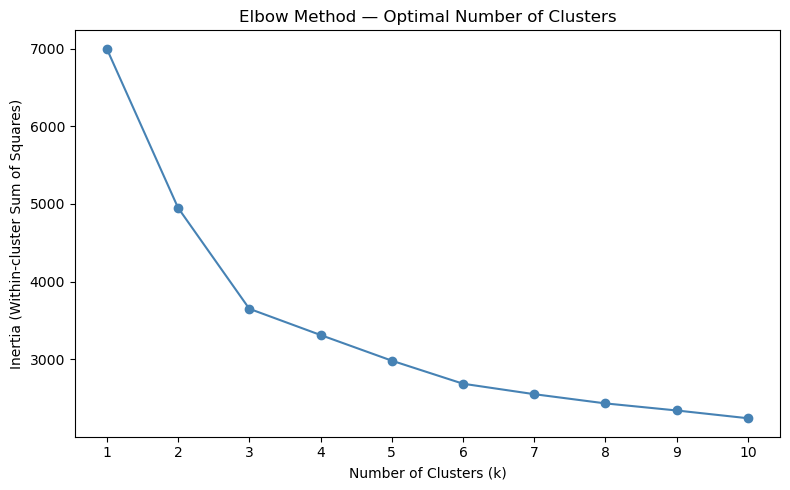

Inertia values:
  k=1: 7000.00
  k=2: 4950.45
  k=3: 3649.45
  k=4: 3311.54
  k=5: 2980.86
  k=6: 2683.59
  k=7: 2548.79
  k=8: 2429.93
  k=9: 2338.75
  k=10: 2238.61


In [32]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_clust_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

print('Inertia values:')
for k, val in zip(k_range, inertia):
    print(f'  k={k}: {val:.2f}')

In [33]:
# Choose optimal k based on elbow — typically k=3 or k=4; inspect plot above
# Here we select k=3 (a common elbow point for datasets with 3 work locations)
OPTIMAL_K = 3

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=0, n_init=10)
rw_df['Cluster'] = kmeans.fit_predict(X_clust_scaled)

print(f'K-Means clustering done with k={OPTIMAL_K}')
print('Cluster distribution:')
print(rw_df['Cluster'].value_counts().sort_index())

K-Means clustering done with k=3
Cluster distribution:
Cluster
0    332
1    339
2    329
Name: count, dtype: int64


## 2.3 Cluster Profiles — Average of Each Variable per Cluster

In [34]:
cluster_means = rw_df.groupby('Cluster')[cluster_features].mean().round(2)
print('Average of each variable per cluster:')
print(cluster_means.to_string())

Average of each variable per cluster:
         Hours_Worked_Per_Week  Number_of_Virtual_Meetings_Per_Week  Stress_Level  Job_Satisfaction  Work_Life_Balance_Rating  Mental_Health_Condition  Productivity_Score
Cluster                                                                                                                                                                   
0                        44.21                                19.28          8.09              2.78                      4.31                     0.57               54.52
1                        39.48                                 9.43          3.75              7.12                      7.12                     0.33               83.93
2                        34.75                                 4.77          7.24              3.93                      5.29                     0.56               59.83


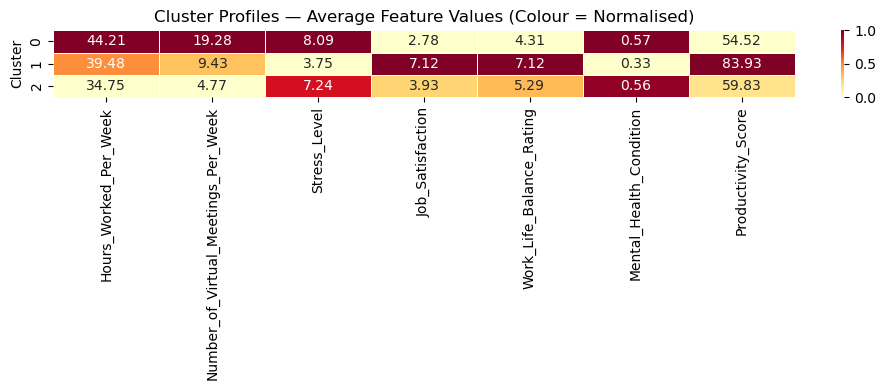

In [35]:
# Visualise cluster profiles as a heatmap
# Normalise for comparison
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

plt.figure(figsize=(10, 4))
sns.heatmap(cluster_means_norm, annot=cluster_means.values, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Profiles — Average Feature Values (Colour = Normalised)')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

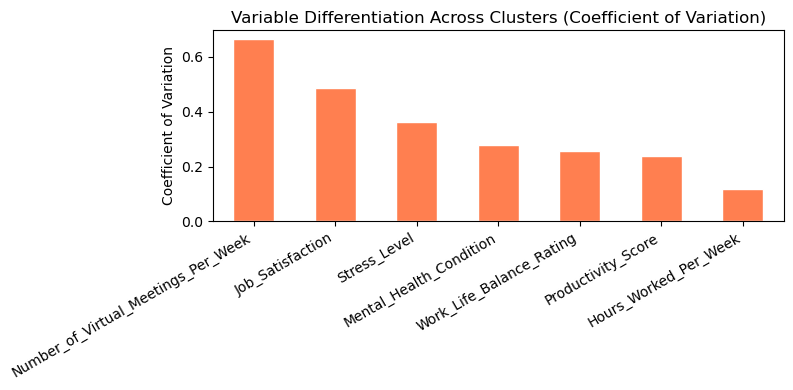

Variables ranked by differentiation (highest to lowest):
Number_of_Virtual_Meetings_Per_Week    0.663807
Job_Satisfaction                       0.487742
Stress_Level                           0.361625
Mental_Health_Condition                0.278978
Work_Life_Balance_Rating               0.255909
Productivity_Score                     0.237142
Hours_Worked_Per_Week                  0.119807


In [36]:
# Most differentiating variables — coefficient of variation across clusters
cv = cluster_means.std() / cluster_means.mean()
cv_sorted = cv.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
cv_sorted.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Variable Differentiation Across Clusters (Coefficient of Variation)')
plt.ylabel('Coefficient of Variation')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Variables ranked by differentiation (highest to lowest):')
print(cv_sorted.to_string())

## 2.4 Identify the "At-Risk" Cluster

In [38]:
# Review cluster means to identify at-risk cluster:
# The at-risk cluster = low Productivity Score, high Stress Level, low Job Satisfaction
print('Cluster means for identification:')
print(cluster_means[['Productivity_Score', 'Stress_Level', 'Job_Satisfaction']])

# Identify at-risk cluster programmatically
# Score each cluster: high stress + low productivity + low satisfaction = at-risk
risk_score = (cluster_means['Stress_Level']
              - cluster_means['Productivity_Score'] / 10
              - cluster_means['Job_Satisfaction'])
at_risk_cluster = risk_score.idxmax()
print(f'\nIdentified at-risk cluster: Cluster {at_risk_cluster}')
print(cluster_means.loc[at_risk_cluster])

Cluster means for identification:
         Productivity_Score  Stress_Level  Job_Satisfaction
Cluster                                                    
0                     54.52          8.09              2.78
1                     83.93          3.75              7.12
2                     59.83          7.24              3.93

Identified at-risk cluster: Cluster 0
Hours_Worked_Per_Week                  44.21
Number_of_Virtual_Meetings_Per_Week    19.28
Stress_Level                            8.09
Job_Satisfaction                        2.78
Work_Life_Balance_Rating                4.31
Mental_Health_Condition                 0.57
Productivity_Score                     54.52
Name: 0, dtype: float64


In [39]:
# Define binary target: 1 = at-risk, 0 = others
rw_df['At_Risk'] = (rw_df['Cluster'] == at_risk_cluster).astype(int)
print('At-Risk distribution:')
print(rw_df['At_Risk'].value_counts())

At-Risk distribution:
At_Risk
0    668
1    332
Name: count, dtype: int64


## 2.5 Logistic Regression — At-Risk Classification

In [40]:
# Prepare features for logistic regression
# Include Work_Location (one-hot encoded) as it was excluded only from clustering
rw_model_df = pd.get_dummies(rw_df[cluster_features + ['Work_Location', 'At_Risk']],
                              columns=['Work_Location'], drop_first=True)

X_lr = rw_model_df.drop(columns=['At_Risk'])
y_lr = rw_model_df['At_Risk']

# Scale features
scaler_lr = StandardScaler()
X_lr_scaled = scaler_lr.fit_transform(X_lr.astype(float))

# Split: 70% train, 30% test, random_state=0
X_tr, X_te, y_tr, y_te = train_test_split(
    X_lr_scaled, y_lr, test_size=0.3, random_state=0
)
print('Train size:', X_tr.shape[0])
print('Test size:', X_te.shape[0])

Train size: 700
Test size: 300


In [41]:
# Logistic Regression model
log_reg = LogisticRegression(random_state=0, max_iter=1000)
log_reg.fit(X_tr, y_tr)

y_pred_lr = log_reg.predict(X_te)

Confusion Matrix:
[[204   0]
 [  0  96]]


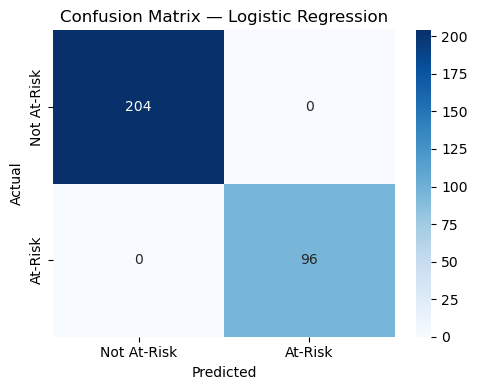

In [42]:
# Confusion matrix
cm = confusion_matrix(y_te, y_pred_lr)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not At-Risk', 'At-Risk'],
            yticklabels=['Not At-Risk', 'At-Risk'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [43]:
# Classification performance
accuracy = accuracy_score(y_te, y_pred_lr)
print(f'Accuracy: {accuracy:.4f}')
print('\nFull Classification Report:')
print(classification_report(y_te, y_pred_lr, target_names=['Not At-Risk', 'At-Risk']))

Accuracy: 1.0000

Full Classification Report:
              precision    recall  f1-score   support

 Not At-Risk       1.00      1.00      1.00       204
     At-Risk       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [1]:
# What do you think about the performance of the model? Can you identify any specific reasons why this performance is (not) expected?
print("""
 MODEL PERFORMANCE 
====================================================================================

The logistic regression model shows very high classification accuracy when predicting
whether an employee is classified as "at risk". At first glance, this strong performance
might appear surprising, but when considering how the target variable was created, the
result becomes much more understandable.

In this analysis, the At_risk variable was not an originally observed label in the dataset.
Instead, it was created based on the results of the K-Means clustering step. The clustering
algorithm grouped employees using the same behavioural and well-being variables such as
stress level, productivity score, job satisfaction, and work-life balance. After identifying
the cluster that showed characteristics of higher stress and lower productivity, that cluster
was labelled as "at risk".

Because the logistic regression model is trained using exactly these same variables,
the model is essentially learning to reproduce the pattern that the clustering algorithm
already identified. In other words, the model is predicting a label that was generated
directly from the same input features. This makes the prediction task relatively easy,
which explains why the accuracy of the model can be very high.

Another reason the model performs well is that the clusters tend to form relatively clear
separations between employee groups. When these groups are clearly distinguished in terms
of stress levels, productivity, and job satisfaction, a simple model such as logistic
regression can learn the relationship between the features and the risk category very
effectively.

However, it is important to note that this performance may not fully represent how the
model would behave in a real-world situation. In practice, employee risk labels might
come from external evaluations such as HR assessments, health surveys, or managerial
observations. These real-world labels could contain more variability and noise than the
cluster-based labels used here.

If the model produces a small number of incorrect predictions, they are likely to occur
for employees whose characteristics lie near the boundaries between clusters. These
employees may have moderate stress levels or productivity scores that place them between
two behavioural patterns, making classification less clear.

Overall, the high accuracy of the model is largely expected because the target variable
is derived from the same data used to train the model. This makes the task easier for the
algorithm, but it also highlights the importance of carefully interpreting model results
when labels are created through unsupervised learning methods.
""")


 MODEL PERFORMANCE 

The logistic regression model shows very high classification accuracy when predicting
whether an employee is classified as "at risk". At first glance, this strong performance
might appear surprising, but when considering how the target variable was created, the
result becomes much more understandable.

In this analysis, the At_risk variable was not an originally observed label in the dataset.
Instead, it was created based on the results of the K-Means clustering step. The clustering
algorithm grouped employees using the same behavioural and well-being variables such as
stress level, productivity score, job satisfaction, and work-life balance. After identifying
the cluster that showed characteristics of higher stress and lower productivity, that cluster
was labelled as "at risk".

Because the logistic regression model is trained using exactly these same variables,
the model is essentially learning to reproduce the pattern that the clustering algorithm
already ident